# Simulación de Procesos Financieros
## Tarea: Puts y Calls con Monte Carlo y Black-Scholes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## Parte 1. Simulación de puts y calls

In [2]:
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1
M = 10000

In [3]:
def precio_bs(S0, K, r, sigma, T, tipo):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if tipo == "call":
        precio = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        precio = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)
    return precio

In [4]:
def precio_montecarlo(S0, K, r, sigma, T, M, tipo):
    Z = np.random.normal(0, 1, M)
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    if tipo == "call":
        payoff = np.maximum(ST - K, 0)
    else:
        payoff = np.maximum(K - ST, 0)
    precio = np.exp(-r*T) * np.mean(payoff)
    return precio

In [5]:
call_mc = precio_montecarlo(S0, K, r, sigma, T, M, "call")
put_mc = precio_montecarlo(S0, K, r, sigma, T, M, "put")

call_bs = precio_bs(S0, K, r, sigma, T, "call")
put_bs = precio_bs(S0, K, r, sigma, T, "put")

print("Call Monte Carlo:", round(call_mc, 4))
print("Call Black-Scholes:", round(call_bs, 4))
print("Diferencia call:", round(abs(call_mc - call_bs), 4))
print()
print("Put Monte Carlo:", round(put_mc, 4))
print("Put Black-Scholes:", round(put_bs, 4))
print("Diferencia put:", round(abs(put_mc - put_bs), 4))

Call Monte Carlo: 10.3935
Call Black-Scholes: 10.4506
Diferencia call: 0.0571

Put Monte Carlo: 5.5977
Put Black-Scholes: 5.5735
Diferencia put: 0.0242


Los dos metodos dan un precio parecido. La diferencia es normal porque Monte Carlo usa numeros aleatorios y siempre va a tener un poco de error. Black-Scholes da el valor exacto porque es una formmula, no una simulacion.

## Parte 2. Sensibilidad

Para cada parametro se deja lo demas fijo en los valores base (S0=100, K=100, r=5%, sigma=20%, T=1) y solo se mueve el que se esta analizando.

In [6]:
precios_S0 = [80, 90, 100, 110, 120]

call_S0 = []
put_S0 = []

for S in precios_S0:
    call_S0.append(precio_montecarlo(S, K, r, sigma, T, M, "call"))
    put_S0.append(precio_montecarlo(S, K, r, sigma, T, M, "put"))

In [7]:
strikes = [80, 90, 100, 110, 120]

call_K = []
put_K = []

for k in strikes:
    call_K.append(precio_montecarlo(S0, k, r, sigma, T, M, "call"))
    put_K.append(precio_montecarlo(S0, k, r, sigma, T, M, "put"))

In [8]:
volatilidades = [0.10, 0.20, 0.30, 0.40, 0.50]

call_sigma = []
put_sigma = []

for v in volatilidades:
    call_sigma.append(precio_montecarlo(S0, K, r, v, T, M, "call"))
    put_sigma.append(precio_montecarlo(S0, K, r, v, T, M, "put"))

In [9]:
tiempos = [0.25, 0.5, 1, 1.5, 2]

call_T = []
put_T = []

for t in tiempos:
    call_T.append(precio_montecarlo(S0, K, r, sigma, t, M, "call"))
    put_T.append(precio_montecarlo(S0, K, r, sigma, t, M, "put"))

In [10]:
tasas = [0.05, 0.10, 0.15, 0.20]

call_r = []
put_r = []

for tasa in tasas:
    call_r.append(precio_montecarlo(S0, K, tasa, sigma, T, M, "call"))
    put_r.append(precio_montecarlo(S0, K, tasa, sigma, T, M, "put"))

## Parte 3. Visualización

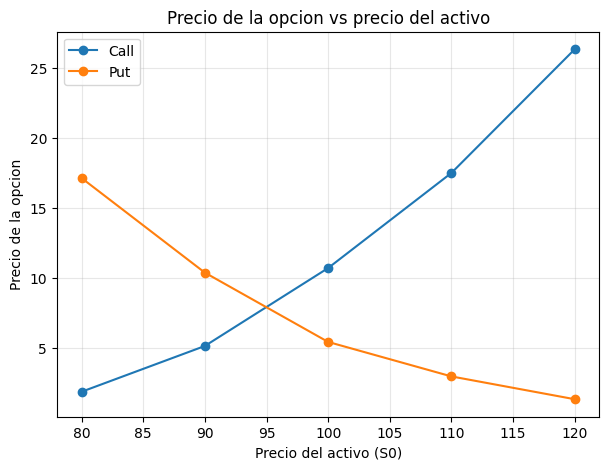

In [11]:
plt.figure(figsize=(7,5))
plt.plot(precios_S0, call_S0, marker="o", label="Call")
plt.plot(precios_S0, put_S0, marker="o", label="Put")
plt.xlabel("Precio del activo (S0)")
plt.ylabel("Precio de la opcion")
plt.title("Precio de la opcion vs precio del activo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

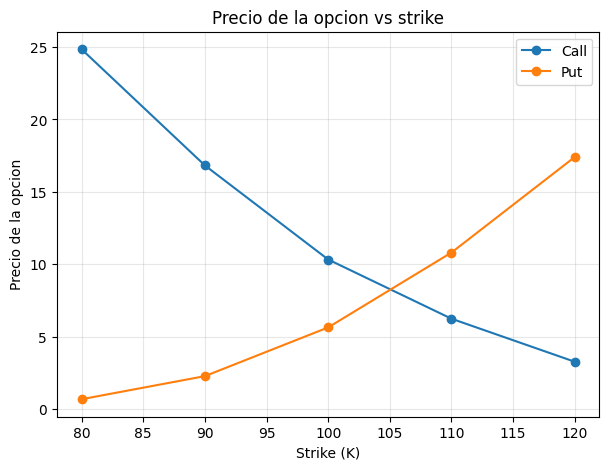

In [12]:
plt.figure(figsize=(7,5))
plt.plot(strikes, call_K, marker="o", label="Call")
plt.plot(strikes, put_K, marker="o", label="Put")
plt.xlabel("Strike (K)")
plt.ylabel("Precio de la opcion")
plt.title("Precio de la opcion vs strike")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

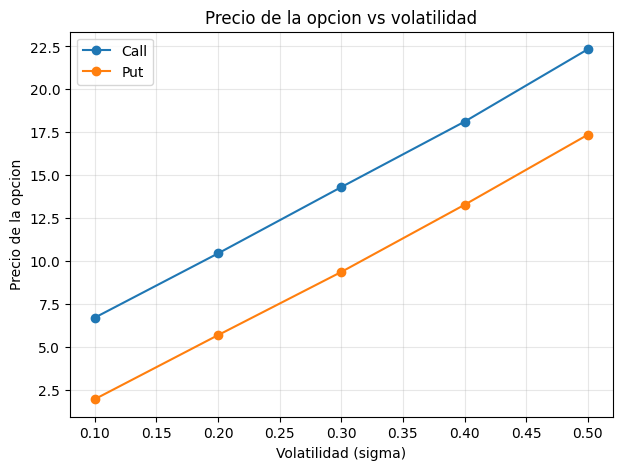

In [13]:
plt.figure(figsize=(7,5))
plt.plot(volatilidades, call_sigma, marker="o", label="Call")
plt.plot(volatilidades, put_sigma, marker="o", label="Put")
plt.xlabel("Volatilidad (sigma)")
plt.ylabel("Precio de la opcion")
plt.title("Precio de la opcion vs volatilidad")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

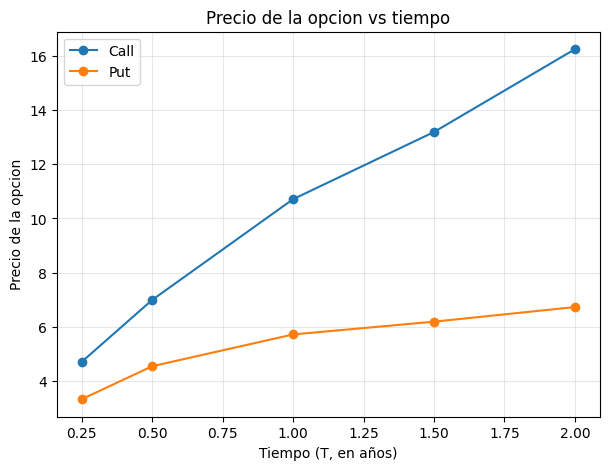

In [14]:
plt.figure(figsize=(7,5))
plt.plot(tiempos, call_T, marker="o", label="Call")
plt.plot(tiempos, put_T, marker="o", label="Put")
plt.xlabel("Tiempo (T, en años)")
plt.ylabel("Precio de la opcion")
plt.title("Precio de la opcion vs tiempo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

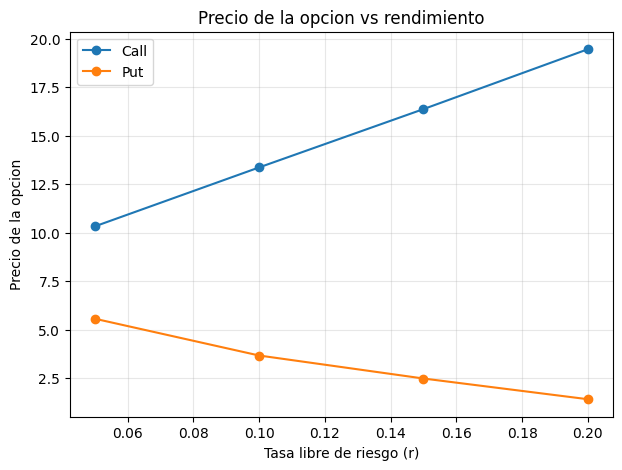

In [15]:
plt.figure(figsize=(7,5))
plt.plot(tasas, call_r, marker="o", label="Call")
plt.plot(tasas, put_r, marker="o", label="Put")
plt.xlabel("Tasa libre de riesgo (r)")
plt.ylabel("Precio de la opcion")
plt.title("Precio de la opcion vs rendimiento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Parte 4. Interpretacion
Precio del activo

Por que una call aumenta cuando aumenta el precio de la accion?
Pues por que el que compra la call gana si el precio sube. Si la accion vale mas, ganas mas lana, tons la call vale mas.

Por que una put se comporta distinto?
Por que la put es lo contrario, aqui ganas cuando el precio baja. Si la accion sube pos ya no te conviene usarla y la put pierde su valor.

Volatilidad

Por que una mayor incertidumbre sube o baja el valor de la opcion?
La volatilidad ase que suba el precio de las dos (call y put). Como nomas puedes perder lo de la prima, si el mercado se mueve a lo loco tienes mas chance de ganar un buen de dinero, por eso valen mas.

Tiempo

Siempre es deseable tener mas tiempo?
Casi siempre si, porque hay mas tiempo pa que el presio se mueva a tu favor. Pero tampoco esta chido tener tu dinero atorado ahi tanto rato sin poder usarlo.

Para quien resulta favorable?
Para el vato que compra la opcion, por que tiene mas dias pa ver si le atino y gana algo.

Strike

Como modifica el strike la probabilidad de terminar in-the-money?
En la call, si el strike esta muy alto esta cañon que el precio lo alcanse, tons es menos probable. En la put es al revez, entre mas alto mas facil que quede abajo.

Definir in-the-money
Es cuando la opcion ya te deja ganancia si la cobras ahorita. En call es cuando el precio esta mas alto que el strike y en put es cuando bajo.

## Parte 4. Comparacion con el mercado

Si fuera invercionista, lo que mas me importaria checar es la volatilidad. En las graficas se ve luego luego que es lo que mas mueve el precio de la call y la put. El strike y el tiempo ya estan fijos desde que la compras, pero la volatilidad cambia adiario y te mueve el valor de la opcion aunque la accion ni se mueva. Por eso es lo mas inportante de vigilar si ya compraste una.